## Project Overview

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import sqlite3

In [114]:
Api_url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"

response = requests.get(Api_url)
data = response.json()
df = pd.DataFrame(data['items'])

### Explore the Dataset

In [115]:
df.head()

,id,node_id,name,full_name,private,owner,html_url,description,fork,url,...,web_commit_signoff_required,has_pull_requests,pull_request_creation_policy,topics,visibility,forks,open_issues,watchers,default_branch,score
0,45717250,MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==,tensorflow,tensorflow/tensorflow,False,"{'login': 'tensorflow', 'id': 15658638, 'node_...",https://github.com/tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,False,https://api.github.com/repos/tensorflow/tensor...,...,False,True,all,"[deep-learning, deep-neural-networks, distribu...",public,76115,2923,197384,master,1.0
1,155220641,MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=,transformers,huggingface/transformers,False,"{'login': 'huggingface', 'id': 25720743, 'node...",https://github.com/huggingface/transformers,🤗 Transformers: the model-definition framework...,False,https://api.github.com/repos/huggingface/trans...,...,False,True,all,"[audio, deep-learning, deepseek, gemma, glm, h...",public,34337,2406,164394,main,1.0
2,343965132,MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=,ML-For-Beginners,microsoft/ML-For-Beginners,False,"{'login': 'microsoft', 'id': 6154722, 'node_id...",https://github.com/microsoft/ML-For-Beginners,"12 weeks, 26 lessons, 52 quizzes, classic Mach...",False,https://api.github.com/repos/microsoft/ML-For-...,...,False,True,all,"[data-science, education, machine-learning, ma...",public,22059,13,89743,main,1.0
3,145553672,MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=,funNLP,fighting41love/funNLP,False,"{'login': 'fighting41love', 'id': 11475294, 'n...",https://github.com/fighting41love/funNLP,中英文敏感词、语言检测、中外手机/电话归属地/运营商查询、名字推断性别、手机号抽取、身份证抽...,False,https://api.github.com/repos/fighting41love/fu...,...,False,True,all,[],public,15278,53,82640,master,1.0
4,21872392,MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==,awesome-machine-learning,josephmisiti/awesome-machine-learning,False,"{'login': 'josephmisiti', 'id': 246302, 'node_...",https://github.com/josephmisiti/awesome-machin...,A curated list of awesome Machine Learning fra...,False,https://api.github.com/repos/josephmisiti/awes...,...,False,True,all,[],public,15620,26,74142,master,1.0


In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 82 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            100 non-null    int64  
 1   node_id                       100 non-null    object 
 2   name                          100 non-null    object 
 3   full_name                     100 non-null    object 
 4   private                       100 non-null    bool   
 5   owner                         100 non-null    object 
 6   html_url                      100 non-null    object 
 7   description                   100 non-null    object 
 8   fork                          100 non-null    bool   
 9   url                           100 non-null    object 
 10  forks_url                     100 non-null    object 
 11  keys_url                      100 non-null    object 
 12  collaborators_url             100 non-null    object 
 13  teams_

In [117]:
df.columns

Index(['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url',
       'description', 'fork', 'url', 'forks_url', 'keys_url',
       'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url',
       'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url',
       'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url',
       'languages_url', 'stargazers_url', 'contributors_url',
       'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url',
       'comments_url', 'issue_comment_url', 'contents_url', 'compare_url',
       'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url',
       'milestones_url', 'notifications_url', 'labels_url', 'releases_url',
       'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url',
       'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size',
       'stargazers_count', 'watchers_count', 'language', 'has_issues',
       'has_projects', 'has_downloads', 'has_wiki', 'has

In [118]:
df.dtypes

,0
id,int64
node_id,object
name,object
full_name,object
private,bool
...,...
forks,int64
open_issues,int64
watchers,int64
default_branch,object


In [119]:
df.isnull().sum()

,0
id,0
node_id,0
name,0
full_name,0
private,0
...,...
forks,0
open_issues,0
watchers,0
default_branch,0


In [144]:
df.describe()

,stargazers_count,forks_count,watchers_count,open_issues_count
count,100.000000,100.000000,100.000000,100.000000
mean,20828.230000,4816.130000,20828.230000,265.470000
std,27319.870513,8772.278374,27319.870513,589.777744
min,7484.000000,498.000000,7484.000000,0.000000
25%,9417.250000,1783.000000,9417.250000,12.000000
50%,13480.500000,2882.000000,13480.500000,32.500000
75%,20265.500000,4437.250000,20265.500000,183.500000
max,197384.000000,76115.000000,197384.000000,2923.000000


# Data Preparation

### Select Required Columns

In [120]:
selected_columns = ['name','owner','language','stargazers_count','forks_count','watchers_count',
                    'open_issues_count','created_at','updated_at','license']

In [121]:
df = df[selected_columns]

In [122]:
df.columns

Index(['name', 'owner', 'language', 'stargazers_count', 'forks_count',
       'watchers_count', 'open_issues_count', 'created_at', 'updated_at',
       'license'],
      dtype='object')

In [123]:
df.shape

(100, 10)

In [124]:
df['owner'].iloc[12]

{'login': 'ZuzooVn',
 'id': 1429230,
 'node_id': 'MDQ6VXNlcjE0MjkyMzA=',
 'avatar_url': 'https://avatars.githubusercontent.com/u/1429230?v=4',
 'gravatar_id': '',
 'url': 'https://api.github.com/users/ZuzooVn',
 'html_url': 'https://github.com/ZuzooVn',
 'followers_url': 'https://api.github.com/users/ZuzooVn/followers',
 'following_url': 'https://api.github.com/users/ZuzooVn/following{/other_user}',
 'gists_url': 'https://api.github.com/users/ZuzooVn/gists{/gist_id}',
 'starred_url': 'https://api.github.com/users/ZuzooVn/starred{/owner}{/repo}',
 'subscriptions_url': 'https://api.github.com/users/ZuzooVn/subscriptions',
 'organizations_url': 'https://api.github.com/users/ZuzooVn/orgs',
 'repos_url': 'https://api.github.com/users/ZuzooVn/repos',
 'events_url': 'https://api.github.com/users/ZuzooVn/events{/privacy}',
 'received_events_url': 'https://api.github.com/users/ZuzooVn/received_events',
 'type': 'User',
 'user_view_type': 'public',
 'site_admin': False}

### Extract Required Values

In [125]:
df['owner_login'] = df['owner'].str['login']

df['license_name'] = df['license'].str['name']

In [126]:
df = df.drop(columns=['owner', 'license'])

In [127]:
df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07T01:19:20Z,2026-08-24T15:21:32Z,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29T13:56:00Z,2026-08-24T15:20:38Z,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03T01:34:05Z,2026-08-24T14:50:30Z,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21T11:20:39Z,2026-08-24T15:21:08Z,fighting41love,None
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15T19:11:19Z,2026-08-24T15:04:49Z,josephmisiti,Other


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               100 non-null    object
 1   language           77 non-null     object
 2   stargazers_count   100 non-null    int64 
 3   forks_count        100 non-null    int64 
 4   watchers_count     100 non-null    int64 
 5   open_issues_count  100 non-null    int64 
 6   created_at         100 non-null    object
 7   updated_at         100 non-null    object
 8   owner_login        100 non-null    object
 9   license_name       78 non-null     object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB


In [129]:
df.describe()

,stargazers_count,forks_count,watchers_count,open_issues_count
count,100.000000,100.000000,100.000000,100.000000
mean,20828.230000,4816.130000,20828.230000,265.470000
std,27319.870513,8772.278374,27319.870513,589.777744
min,7484.000000,498.000000,7484.000000,0.000000
25%,9417.250000,1783.000000,9417.250000,12.000000
50%,13480.500000,2882.000000,13480.500000,32.500000
75%,20265.500000,4437.250000,20265.500000,183.500000
max,197384.000000,76115.000000,197384.000000,2923.000000


In [130]:
df.columns

Index(['name', 'language', 'stargazers_count', 'forks_count', 'watchers_count',
       'open_issues_count', 'created_at', 'updated_at', 'owner_login',
       'license_name'],
      dtype='object')

In [131]:
df.dtypes

,0
name,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,object
updated_at,object
owner_login,object
license_name,object


In [132]:
df.isnull().sum()

,0
name,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,22


In [133]:
df.shape

(100, 10)

### Handle Duplicate Records

In [134]:
df.duplicated().sum()

np.int64(0)

In [135]:
df = df.drop_duplicates()

In [136]:
df.duplicated().sum()

np.int64(0)

### Handle Missing Values

In [137]:
df.isnull().sum()

,0
name,0
language,23
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,22


In [138]:
df['language'] = df['language'].fillna('Unknown')
df['license_name'] = df['license_name'].fillna('Unknown')

In [139]:
df.isnull().sum()

,0
name,0
language,0
stargazers_count,0
forks_count,0
watchers_count,0
open_issues_count,0
created_at,0
updated_at,0
owner_login,0
license_name,0


In [140]:
df.dtypes

,0
name,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,object
updated_at,object
owner_login,object
license_name,object


### Prepare the Dataset

In [141]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['updated_at'] = pd.to_datetime(df['updated_at'])

In [145]:
df = df.rename(columns={'stargazers_count':'stars'})
df = df.rename(columns={'forks_count':'forks'})
df = df.rename(columns={'watchers_count':'watchers'})
df = df.rename(columns={'open_issues_count':'open_issues'})
df = df.rename(columns={'created_at':'created_date'})
df = df.rename(columns={'updated_at':'updated_date'})

In [143]:
df.head()

,name,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other


In [142]:
df.dtypes

,0
name,object
language,object
stargazers_count,int64
forks_count,int64
watchers_count,int64
open_issues_count,int64
created_at,"datetime64[ns, UTC]"
updated_at,"datetime64[ns, UTC]"
owner_login,object
license_name,object


### Save & Verify the Dataset

In [147]:
df.to_csv('github_projects.csv', index=False)

In [148]:
df_check = pd.read_csv('github_projects.csv')

In [149]:
df_check.head()

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other


In [ ]:
df_check.dtypes

In [150]:
conn = sqlite3.connect('github_projects.db')

In [151]:
df.to_sql('Repositories', conn, if_exists='replace', index=False)

100

# SQL Analysis

In [152]:
query = """
SELECT *
FROM Repositories
LIMIT 5;
"""
pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other


In [153]:
query = """
select *
from Repositories
where stars > 10000
order by stars desc;
"""
pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
...,...,...,...,...,...,...,...,...,...,...
65,machine-learning-systems-design,HTML,10543,1633,10543,11,2019-11-24 23:16:28+00:00,2026-08-24 10:37:59+00:00,chiphuyen,Unknown
66,Machine-Learning,Python,10373,5064,10373,7,2017-03-25 07:32:37+00:00,2026-08-24 12:21:10+00:00,Jack-Cherish,Unknown
67,machine-learning-notes,Jupyter Notebook,10341,1826,10341,28,2018-02-15 15:42:33+00:00,2026-08-24 10:39:11+00:00,roboticcam,Unknown
68,3D-Machine-Learning,Unknown,10191,1797,10191,21,2017-08-12 15:20:54+00:00,2026-08-21 09:19:46+00:00,timzhang642,Unknown


In [154]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
1,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36486,7461,36486,68,2021-01-02 12:08:37+00:00,2026-08-24 14:56:16+00:00,ashishpatel26,Unknown
2,machine-learning-for-software-engineers,Unknown,28867,6147,28867,32,2016-10-09 21:20:25+00:00,2026-08-24 14:03:45+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 I...
3,homemade-machine-learning,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,trekhleb,MIT License
4,awesome-production-machine-learning,Unknown,20864,2590,20864,31,2018-08-15 14:28:41+00:00,2026-08-24 09:28:38+00:00,EthicalML,MIT License
5,machine-learning-for-trading,Jupyter Notebook,20603,5551,20603,8,2018-05-09 12:33:08+00:00,2026-08-24 15:19:11+00:00,stefan-jansen,MIT License
6,stanford-cs-229-machine-learning,Unknown,20153,4253,20153,20,2018-08-04 23:01:00+00:00,2026-08-24 14:21:35+00:00,afshinea,MIT License
7,Machine-Learning-Tutorials,Unknown,18142,3969,18142,47,2015-09-12 14:51:38+00:00,2026-08-24 15:17:53+00:00,ujjwalkarn,Creative Commons Zero v1.0 Universal
8,machine-learning-zoomcamp,Jupyter Notebook,14005,3106,14005,3,2020-04-17 04:29:23+00:00,2026-08-24 14:34:43+00:00,DataTalksClub,Unknown
9,machine-learning-interview,Unknown,12792,2046,12792,9,2020-08-11 06:26:32+00:00,2026-08-24 13:45:11+00:00,khangich,Unknown


In [155]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%'
AND language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
1,Machine-Learning,Python,10373,5064,10373,7,2017-03-25 07:32:37+00:00,2026-08-24 12:21:10+00:00,Jack-Cherish,Unknown
2,machine_learning_examples,Python,8913,6402,8913,33,2014-07-31 23:40:45+00:00,2026-08-24 12:01:03+00:00,lazyprogrammer,Unknown
3,financial-machine-learning,Python,8757,1410,8757,15,2019-03-21 21:00:35+00:00,2026-08-24 08:59:21+00:00,firmai,Unknown
4,MachineLearning_Python,Python,8582,2515,8582,10,2016-10-17 15:44:59+00:00,2026-08-24 01:16:06+00:00,lawlite19,MIT License
5,Machine-Learning-Collection,Python,8488,2784,8488,118,2020-03-26 07:02:40+00:00,2026-08-24 07:23:55+00:00,aladdinpersson,MIT License


In [156]:
query = """
SELECT *
FROM Repositories
where name LIKE '%algorithm%'
and language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,MLAlgorithms,Python,11168,1768,11168,10,2016-10-05 06:46:45+00:00,2026-08-24 08:07:27+00:00,rushter,MIT License


In [157]:
query = """
SELECT *
FROM Repositories
WHERE language LIKE '%Jupyter Notebook%'
OR name = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
1,shap,Jupyter Notebook,25699,3746,25699,1009,2016-11-22 19:17:08+00:00,2026-08-24 03:00:07+00:00,shap,MIT License
2,homemade-machine-learning,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,trekhleb,MIT License
3,machine-learning-for-trading,Jupyter Notebook,20603,5551,20603,8,2018-05-09 12:33:08+00:00,2026-08-24 15:19:11+00:00,stefan-jansen,MIT License
4,ML-NLP,Jupyter Notebook,17798,4627,17798,36,2019-07-05 12:49:53+00:00,2026-08-24 11:55:46+00:00,NLP-LOVE,Unknown
5,mml-book.github.io,Jupyter Notebook,15918,2854,15918,197,2017-12-08 10:52:21+00:00,2026-08-24 13:50:29+00:00,mml-book,Unknown
6,machine-learning-zoomcamp,Jupyter Notebook,14005,3106,14005,3,2020-04-17 04:29:23+00:00,2026-08-24 14:34:43+00:00,DataTalksClub,Unknown
7,handson-ml3,Jupyter Notebook,13990,5262,13990,107,2022-02-19 09:43:22+00:00,2026-08-24 14:46:05+00:00,ageron,Apache License 2.0
8,python-machine-learning-book,Jupyter Notebook,12643,4373,12643,13,2015-08-07 20:39:29+00:00,2026-08-24 10:22:13+00:00,rasbt,MIT License
9,amazon-sagemaker-examples,Jupyter Notebook,10980,6961,10980,849,2017-10-23 05:55:22+00:00,2026-08-23 12:50:33+00:00,aws,Apache License 2.0


In [158]:
query = """
SELECT *
FROM Repositories
WHERE name LIKE '%Machine%'
or language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
1,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
2,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
3,scikit-learn,Python,67048,27308,67048,2128,2010-08-17 09:43:38+00:00,2026-08-24 14:01:26+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
4,gradio,Python,43412,3579,43412,170,2018-12-19 08:24:04+00:00,2026-08-24 11:30:54+00:00,gradio-app,Apache License 2.0
5,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36486,7461,36486,68,2021-01-02 12:08:37+00:00,2026-08-24 14:56:16+00:00,ashishpatel26,Unknown
6,ML-From-Scratch,Python,32516,5431,32516,77,2017-02-05 12:11:23+00:00,2026-08-24 11:58:16+00:00,eriklindernoren,MIT License
7,machine-learning-for-software-engineers,Unknown,28867,6147,28867,32,2016-10-09 21:20:25+00:00,2026-08-24 14:03:45+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 I...
8,linkedin-skill-assessments-quizzes,Python,28806,12905,28806,21,2019-07-13 19:52:56+00:00,2026-08-23 19:50:04+00:00,Ebazhanov,GNU Affero General Public License v3.0
9,cs249r_book,Python,27994,3534,27994,26,2023-09-06 19:31:06+00:00,2026-08-24 12:32:02+00:00,harvard-edge,Other


In [159]:
query = """
SELECT *
FROM Repositories
where not license_name = 'Apache License 2.0';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
1,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
2,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
3,scikit-learn,Python,67048,27308,67048,2128,2010-08-17 09:43:38+00:00,2026-08-24 14:01:26+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
4,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36486,7461,36486,68,2021-01-02 12:08:37+00:00,2026-08-24 14:56:16+00:00,ashishpatel26,Unknown
...,...,...,...,...,...,...,...,...,...,...
74,Machine-Learning-Specialization-Coursera,Jupyter Notebook,7808,3729,7808,26,2022-06-16 15:31:02+00:00,2026-08-24 09:38:33+00:00,greyhatguy007,MIT License
75,Machine-learning-learning-notes,Unknown,7763,1879,7763,28,2018-03-24 06:48:10+00:00,2026-08-24 10:24:38+00:00,Vay-keen,Unknown
76,awesome-youtubers,Markdown,7747,498,7747,2,2020-08-25 14:18:15+00:00,2026-08-24 09:36:47+00:00,JoseDeFreitas,Creative Commons Zero v1.0 Universal
77,Learn_Machine_Learning_in_3_Months,Unknown,7603,2311,7603,19,2018-03-02 10:59:53+00:00,2026-08-21 16:08:33+00:00,llSourcell,Unknown


In [160]:
query = """
SELECT *
FROM Repositories
where not license_name = 'Apache License 2.0'
and not language = 'Python';
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
1,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36486,7461,36486,68,2021-01-02 12:08:37+00:00,2026-08-24 14:56:16+00:00,ashishpatel26,Unknown
2,C-Plus-Plus,C++,34599,7854,34599,28,2016-07-16 10:19:45+00:00,2026-08-24 12:02:18+00:00,TheAlgorithms,MIT License
3,netron,JavaScript,33396,3176,33396,18,2010-12-26 12:53:43+00:00,2026-08-24 14:32:46+00:00,lutzroeder,MIT License
4,applied-ml,Unknown,30080,3992,30080,8,2020-07-04 18:57:47+00:00,2026-08-24 15:19:03+00:00,eugeneyan,MIT License
5,machine-learning-for-software-engineers,Unknown,28867,6147,28867,32,2016-10-09 21:20:25+00:00,2026-08-24 14:03:45+00:00,ZuzooVn,Creative Commons Attribution Share Alike 4.0 I...
6,shap,Jupyter Notebook,25699,3746,25699,1009,2016-11-22 19:17:08+00:00,2026-08-24 03:00:07+00:00,shap,MIT License
7,homemade-machine-learning,Jupyter Notebook,24774,4194,24774,30,2018-11-01 04:34:19+00:00,2026-08-23 16:53:03+00:00,trekhleb,MIT License
8,best-of-ml-python,Unknown,23731,3146,23731,54,2020-11-29 19:41:36+00:00,2026-08-24 09:28:03+00:00,lukasmasuch,Creative Commons Attribution Share Alike 4.0 I...
9,C,C,22340,4770,22340,18,2016-07-16 10:17:03+00:00,2026-08-24 05:37:11+00:00,TheAlgorithms,GNU General Public License v3.0


In [161]:
query = """
SELECT *
FROM Repositories
ORDER BY stars DESC
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
...,...,...,...,...,...,...,...,...,...,...
95,Machine-learning-learning-notes,Unknown,7763,1879,7763,28,2018-03-24 06:48:10+00:00,2026-08-24 10:24:38+00:00,Vay-keen,Unknown
96,awesome-youtubers,Markdown,7747,498,7747,2,2020-08-25 14:18:15+00:00,2026-08-24 09:36:47+00:00,JoseDeFreitas,Creative Commons Zero v1.0 Universal
97,Learn_Machine_Learning_in_3_Months,Unknown,7603,2311,7603,19,2018-03-02 10:59:53+00:00,2026-08-21 16:08:33+00:00,llSourcell,Unknown
98,h2o-3,Jupyter Notebook,7495,2025,7495,2883,2014-03-03 16:08:07+00:00,2026-08-21 06:04:07+00:00,h2oai,Apache License 2.0


In [162]:
query = """
SELECT *
FROM Repositories
ORDER BY stars DESC
LIMIT 10;
"""

pd.read_sql_query(query, conn)

,name,language,stars,forks,watchers,open_issues,created_date,updated_date,owner_login,license_name
0,tensorflow,C++,197384,76115,197384,2923,2015-11-07 01:19:20+00:00,2026-08-24 15:21:32+00:00,tensorflow,Apache License 2.0
1,transformers,Python,164394,34337,164394,2406,2018-10-29 13:56:00+00:00,2026-08-24 15:20:38+00:00,huggingface,Apache License 2.0
2,ML-For-Beginners,Jupyter Notebook,89743,22059,89743,13,2021-03-03 01:34:05+00:00,2026-08-24 14:50:30+00:00,microsoft,MIT License
3,funNLP,Python,82640,15278,82640,53,2018-08-21 11:20:39+00:00,2026-08-24 15:21:08+00:00,fighting41love,Unknown
4,awesome-machine-learning,Python,74142,15620,74142,26,2014-07-15 19:11:19+00:00,2026-08-24 15:04:49+00:00,josephmisiti,Other
5,scikit-learn,Python,67048,27308,67048,2128,2010-08-17 09:43:38+00:00,2026-08-24 14:01:26+00:00,scikit-learn,"BSD 3-Clause ""New"" or ""Revised"" License"
6,gradio,Python,43412,3579,43412,170,2018-12-19 08:24:04+00:00,2026-08-24 11:30:54+00:00,gradio-app,Apache License 2.0
7,500-AI-Machine-learning-Deep-learning-Computer...,Unknown,36486,7461,36486,68,2021-01-02 12:08:37+00:00,2026-08-24 14:56:16+00:00,ashishpatel26,Unknown
8,C-Plus-Plus,C++,34599,7854,34599,28,2016-07-16 10:19:45+00:00,2026-08-24 12:02:18+00:00,TheAlgorithms,MIT License
9,netron,JavaScript,33396,3176,33396,18,2010-12-26 12:53:43+00:00,2026-08-24 14:32:46+00:00,lutzroeder,MIT License


In [163]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories;
"""

pd.read_sql_query(query, conn)

,total_repositories
0,100


In [164]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories;
"""

pd.read_sql_query(query, conn)

,average_stars
0,20828.23


In [165]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories

GROUP BY language;

"""

pd.read_sql_query(query, conn)

,language,repository_count
0,C,1
1,C#,2
2,C++,12
3,CSS,1
4,Go,3
5,HTML,2
6,Java,1
7,JavaScript,3
8,Jupyter Notebook,19
9,Markdown,1


In [166]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
having COUNT(*) > 5;

"""
pd.read_sql_query(query, conn)


,language,repository_count
0,C++,12
1,Jupyter Notebook,19
2,Python,30
3,Unknown,23


# Data Visualization

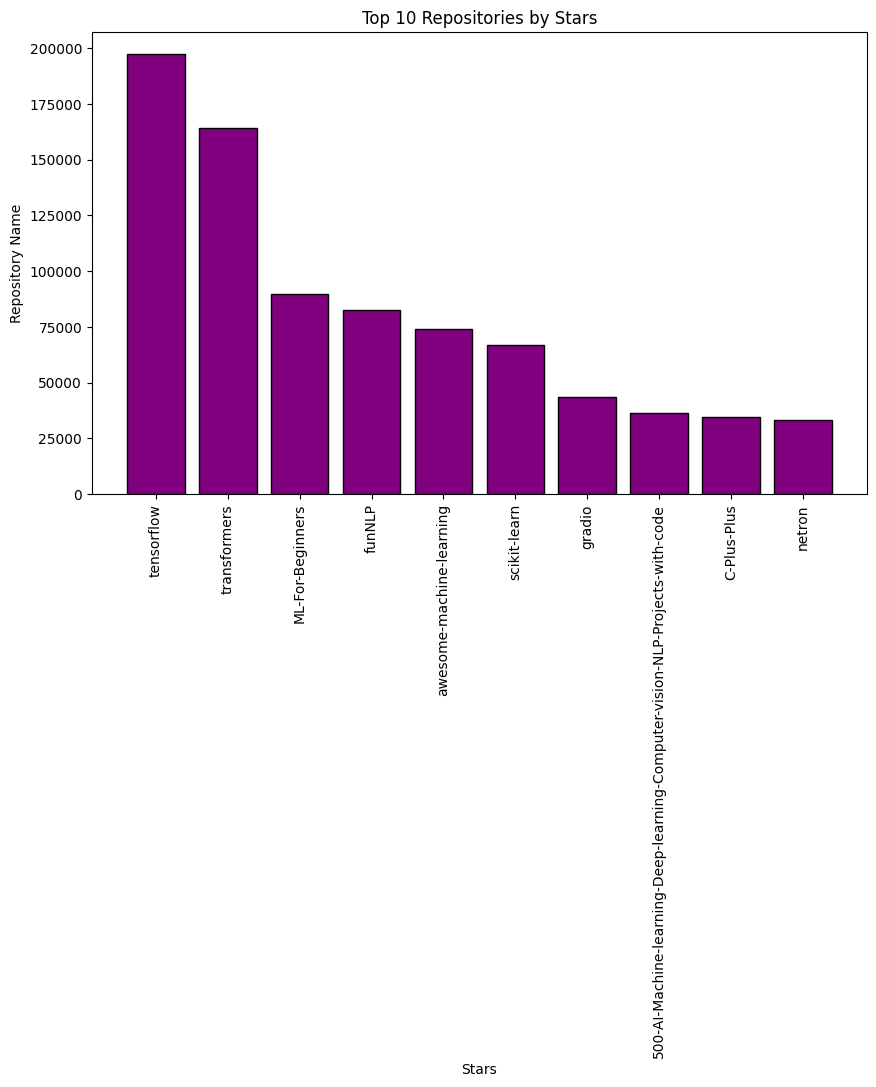

In [192]:
query = """
SELECT name, stars
FROM Repositories
order by stars desc
limit 10;
"""
top_10 = pd.read_sql_query(query, conn)
plt.figure(figsize=(10, 6))

plt.bar(top_10['name'], top_10['stars'], color='purple', edgecolor='black')

plt.xlabel('Stars')
plt.xticks(rotation=90)

plt.ylabel('Repository Name')
plt.title('Top 10 Repositories by Stars')

plt.show()


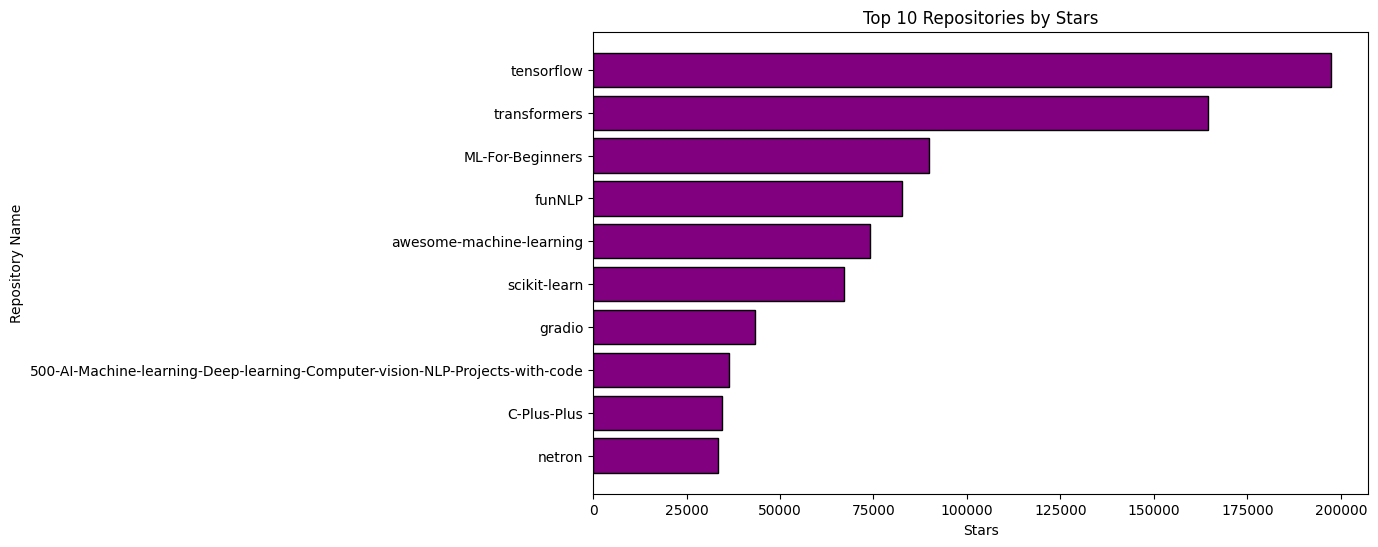

In [193]:
query = """
SELECT name, stars
FROM Repositories
order by stars desc
limit 10
"""
top_10 = pd.read_sql_query(query, conn)
plt.figure(figsize=(10, 6))

plt.barh(top_10['name'], top_10['stars'], color='purple', edgecolor='black')

plt.xlabel('Stars')
plt.ylabel('Repository Name')
plt.title('Top 10 Repositories by Stars')

plt.gca().invert_yaxis()

plt.show()

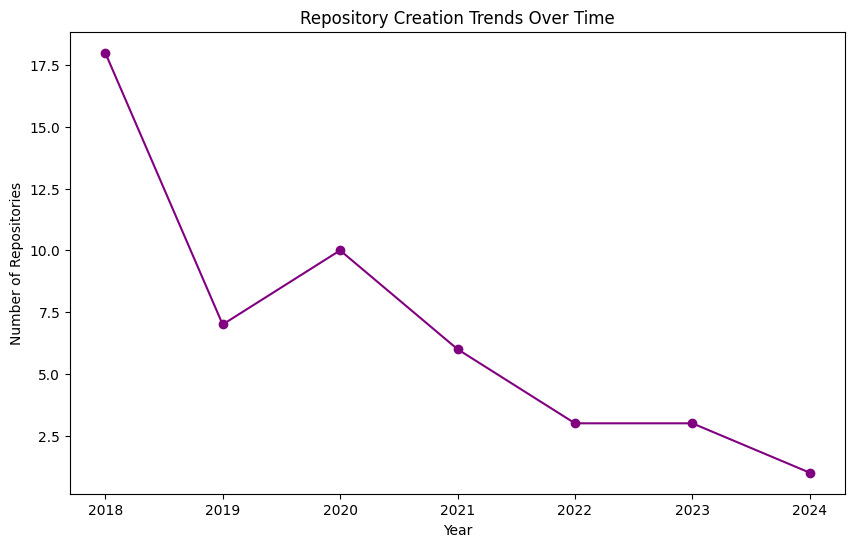

In [212]:
query = """
SELECT created_date
FROM Repositories;
"""

dates = pd.read_sql_query(query, conn)

dates['created_date'] = pd.to_datetime(dates['created_date'])
dates['year'] = dates['created_date'].dt.year

year_count = dates['year'].value_counts().sort_index()

recent_years = year_count.tail(7)

plt.figure(figsize=(10, 6))

plt.plot(recent_years.index, recent_years.values, marker='o', linestyle='solid', color='purple')

plt.xlabel('Year')
plt.ylabel('Number of Repositories')
plt.title('Repository Creation Trends Over Time')

plt.xticks(recent_years.index)

plt.show()